# 📊 CFO Case Study: Financial Analysis & Strategic Decision-Making

## 🎯 Objective

This project simulates the role of a Chief Financial Officer (CFO) by analyzing a retail dataset to extract actionable business insights and support strategic decision-making.

## 📦 Dataset

Superstore dataset containing sales transactions, including revenue, profit, discounts, customer and regional data.

## 🧠 Methodology

- Data cleaning and preparation  
- KPI analysis  
- Profitability analysis (category, region, customer)  
- Discount impact evaluation  
- Time series analysis  
- Strategic recommendations  



In [37]:
import pandas as pd
import matplotlib.pyplot as plt

# Cargar datos
df = pd.read_csv('../data/Sample - Superstore.csv', encoding='latin1')

# Ver primeras filas
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [38]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [39]:
#Se procede a convertir fecha
df['Order Date'] = pd.to_datetime(df['Order Date'])

#Creamos columna mes
df['YearMonth'] = df['Order Date'].dt.to_period('M')

## 📈 Revenue Trend Analysis

The company shows a clear upward trend in revenue over time, although with high volatility.

### Key Insights:
- Revenue is growing overall
- Significant fluctuations suggest instability
- Potential seasonality patterns

### Business Interpretation:
- Growth is positive but unpredictable
- Financial planning and forecasting should be improved

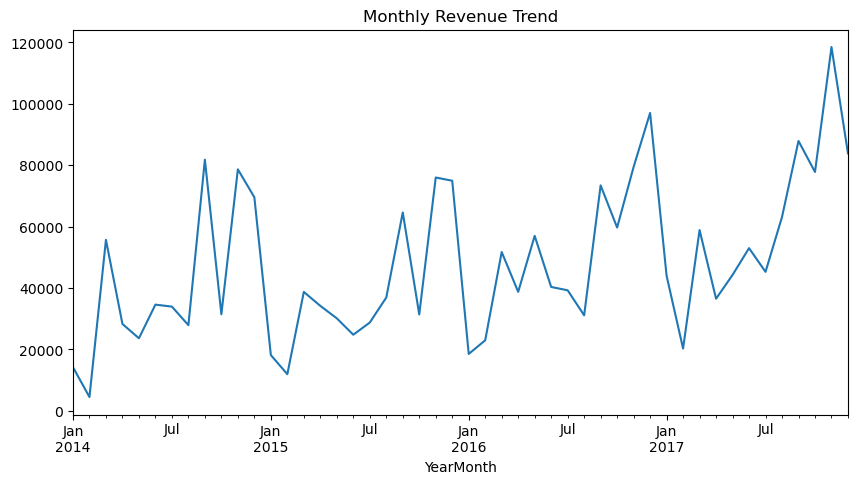

In [40]:
monthly_sales = df.groupby('YearMonth')['Sales'].sum()

monthly_sales.plot(figsize=(10,5), title="Monthly Revenue Trend")
plt.show()

In [41]:
# Revenue y profit por categoría
category_analysis = df.groupby('Category').agg({
    'Sales': 'sum',
    'Profit': 'sum'
})

category_analysis['Margin'] = category_analysis['Profit'] / category_analysis['Sales']

category_analysis.sort_values(by='Profit', ascending=False)

,Sales,Profit,Margin
Category,,,
Technology,836154.0330,145454.9481,0.173957
Office Supplies,719047.0320,122490.8008,0.170352
Furniture,741999.7953,18451.2728,0.024867


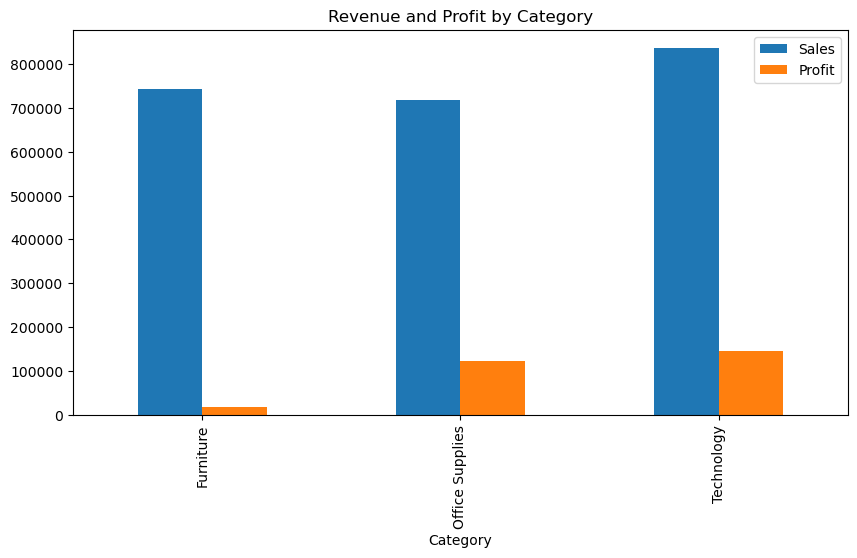

In [42]:
category_analysis[['Sales', 'Profit']].plot(kind='bar', figsize=(10,5), title='Revenue and Profit by Category')
plt.show()

## 💰 Category Performance Analysis / Análisis por categoría

This analysis compares revenue and profitability across product categories.

Key insights:
- Technology shows strong performance with high revenue and healthy margins
- Office Supplies is stable and consistent
- Furniture generates high revenue but very low profitability

⚠️ Critical finding:
Furniture is significantly underperforming in terms of margin (~2%), suggesting potential pricing, cost, or operational inefficiencies.



## 🧠 CFO Perspective: Strategic Decisions / Decisiones estratégicas

Based on the analysis, the following actions would be considered:

### 💡 Profitability Optimization
- Review pricing strategy in Furniture category
- Analyze cost structure and supplier efficiency
- Consider discontinuing low-margin products

### 💡 Capital Allocation
- Increase investment in Technology due to strong margins
- Maintain Office Supplies as stable revenue stream

### 💡 Risk Management
- Reduce dependency on low-margin segments
- Improve monitoring of category-level profitability



In [43]:
#Análisis por región
region_analysis = df.groupby('Region').agg({
    'Sales': 'sum',
    'Profit': 'sum'
})

region_analysis['Margin'] = region_analysis['Profit'] / region_analysis['Sales']

region_analysis.sort_values(by='Profit', ascending=False)

,Sales,Profit,Margin
Region,,,
West,725457.8245,108418.4489,0.149448
East,678781.2400,91522.7800,0.134834
South,391721.9050,46749.4303,0.119343
Central,501239.8908,39706.3625,0.079216


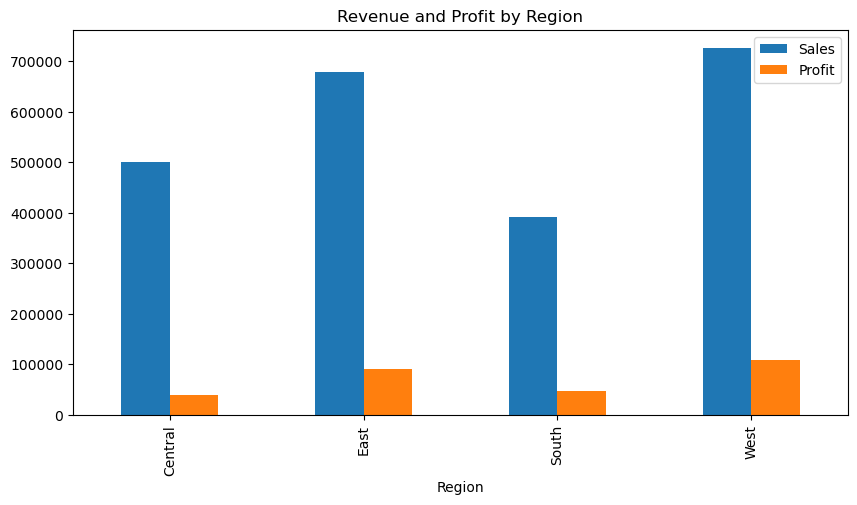

In [44]:
region_analysis[['Sales', 'Profit']].plot(kind='bar', figsize=(10,5), title='Revenue and Profit by Region')
plt.show()

## 🌍 Regional Performance Analysis / Análisis por región

This analysis evaluates financial performance across regions.

Key insights:
- West and East are the strongest regions, with high revenue and solid margins
- South shows moderate performance
- Central significantly underperforms in profitability

⚠️ Critical finding:
The Central region has the lowest margin (~7%), indicating inefficiencies or cost issues.



## 🧠 Strategic Actions by Region / Decisiones por región

### 💡 Central Region (Critical)
- Conduct cost structure analysis
- Review pricing strategy
- Evaluate operational inefficiencies
- Consider restructuring or reducing exposure

### 💡 West & East (Growth Engines)
- Increase investment
- Expand high-performing segments
- Leverage best practices

### 💡 South (Optimization)
- Improve efficiency
- Identify growth opportunities



In [45]:
# KPIs clave

total_orders = df['Order ID'].nunique()
total_customers = df['Customer ID'].nunique()

aov = df['Sales'].sum() / total_orders
profit_per_order = df['Profit'].sum() / total_orders
sales_per_customer = df['Sales'].sum() / total_customers

print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print("AOV:", round(aov, 2))
print("Profit per Order:", round(profit_per_order, 2))
print("Sales per Customer:", round(sales_per_customer, 2))

Total Orders: 5009
Total Customers: 793
AOV: 458.61
Profit per Order: 57.18
Sales per Customer: 2896.85


In [46]:
#Análisis por clientes
customer_analysis = df.groupby('Customer Name').agg({
    'Sales': 'sum',
    'Profit': 'sum'
}).sort_values(by='Profit', ascending=False)

customer_analysis.head(10)

,Sales,Profit
Customer Name,,
Tamara Chand,19052.218,8981.3239
Raymond Buch,15117.339,6976.0959
Sanjit Chand,14142.334,5757.4119
Hunter Lopez,12873.298,5622.4292
Adrian Barton,14473.571,5444.8055
Tom Ashbrook,14595.620,4703.7883
Christopher Martinez,8954.020,3899.8904
Keith Dawkins,8181.256,3038.6254
Andy Reiter,6608.448,2884.6208


In [47]:
customer_analysis.sort_values(by='Profit').head(10)

,Sales,Profit
Customer Name,,
Cindy Stewart,5690.055,-6626.3895
Grant Thornton,9351.212,-4108.6589
Luke Foster,3930.509,-3583.9770
Sharelle Roach,3233.481,-3333.9144
Henry Goldwyn,3247.642,-2797.9635
Nathan Cano,2218.990,-2204.8072
Sean Braxton,8057.891,-2082.7451
Sean Miller,25043.050,-1980.7393
Christine Phan,5888.275,-1850.3029


In [48]:
#Cómo impactan los descuentos?
discount_analysis = df.groupby('Discount').agg({
    'Sales': 'sum',
    'Profit': 'sum'
}).reset_index()

discount_analysis

,Discount,Sales,Profit
0,0.00,1.087908e+06,320987.6032
1,0.10,5.436935e+04,9029.1770
2,0.15,2.755852e+04,1418.9915
3,0.20,7.645944e+05,90337.3060
4,0.30,1.032267e+05,-10369.2774
5,0.32,1.449346e+04,-2391.1377
6,0.40,1.164178e+05,-23057.0504
7,0.45,5.484974e+03,-2493.1111
8,0.50,5.891854e+04,-20506.4281
9,0.60,6.644700e+03,-5944.6552


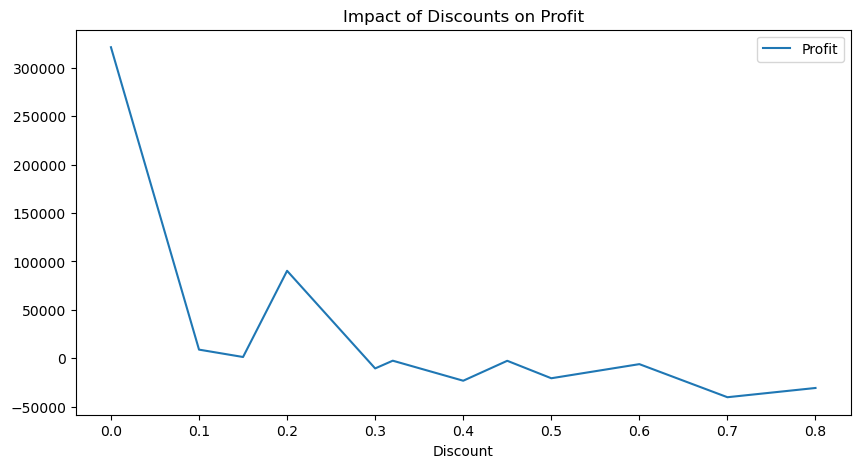

In [49]:
discount_analysis.plot(x='Discount', y='Profit', kind='line', figsize=(10,5), title='Impact of Discounts on Profit')
plt.show()

## 💥 Key Business Insights

### 1. Profitability Issues
- Furniture has extremely low margins (~2%)
- Indicates pricing or cost inefficiencies

### 2. Discount Strategy Risk
- Higher discounts strongly reduce profitability
- Evidence of over-discounting

### 3. Customer Profitability
- Some customers generate negative profit
- Revenue ≠ profitability

### 4. Regional Performance Gap
- Central region significantly underperforms
- Potential operational inefficiencies

### 5. Revenue Volatility
- High fluctuations in monthly sales
- Risk for forecasting and financial planning

## 🧠 CFO Strategic Plan

### 💰 Profit Optimization
- Reduce exposure to low-margin products (Furniture)
- Adjust pricing strategy

### 📉 Discount Control
- Limit high-discount transactions
- Implement discount thresholds

### 👥 Customer Strategy
- Focus on high-profit customers
- Reassess or renegotiate unprofitable accounts

### 🌍 Regional Strategy
- Investigate Central region inefficiencies
- Scale high-performing regions (West & East)

### 📊 Financial Planning
- Improve forecasting models to reduce volatility